In [1]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [2]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
import segmentation_models_pytorch as smp

import torch.nn as nn
import torch.optim as optim

from torchmetrics.classification import MulticlassAccuracy
from torchmetrics.classification import MulticlassPrecision
from torchmetrics.classification import MulticlassRecall
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassJaccardIndex

In [3]:
IMAGE_DIR = "/kaggle/input/datasets/rushikeshraghatate/segmentation/unet_dataset/images"
MASK_DIR = "/kaggle/input/datasets/rushikeshraghatate/segmentation/unet_dataset/masks"

print("Images:", len(os.listdir(IMAGE_DIR)))
print("Masks:", len(os.listdir(MASK_DIR)))

Images: 1047
Masks: 1047


In [4]:
CLASS_NAMES = {
    0: "Background",
    1: "Bone",
    2: "Decayed Teeth",
    3: "Healthy Teeth",
    4: "Implant Teeth",
    5: "Restored Teeth"
}

NUM_CLASSES = len(CLASS_NAMES)

In [5]:
pixel_counts = np.zeros(NUM_CLASSES)

for file in os.listdir(MASK_DIR):
    path = os.path.join(MASK_DIR, file)
    mask = np.array(Image.open(path).convert("L"))

    for i in range(NUM_CLASSES):
        pixel_counts[i] += np.sum(mask == i)

pixel_counts = np.where(pixel_counts == 0, 1, pixel_counts)
total_pixels = np.sum(pixel_counts)

# 🔥 LOG-SCALED WEIGHTS (FIXED)
class_weights = np.log(1 + (total_pixels / pixel_counts))
class_weights = class_weights / np.sum(class_weights) * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class Weights:", class_weights)

Class Weights: tensor([0.8422, 0.6260, 0.8795, 0.8509, 1.9426, 0.8588])


In [6]:
images = os.listdir(IMAGE_DIR)

train, val = train_test_split(images, test_size=0.2, random_state=42)
val, test = train_test_split(val, test_size=0.5, random_state=42)

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Train: 837
Validation: 105
Test: 105


In [7]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

val_transform = A.Compose([])

In [8]:
class DentalDataset(Dataset):

    def __init__(self, file_list, transform=None):
        self.files = file_list
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        img_path = os.path.join(IMAGE_DIR, name)
        mask_path = os.path.join(MASK_DIR, os.path.splitext(name)[0] + ".png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"]

        image = image.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        image = (image - mean) / std
        image = np.transpose(image, (2, 0, 1))

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [9]:
train_loader = DataLoader(DentalDataset(train, train_transform), batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(DentalDataset(val, val_transform), batch_size=4, num_workers=2, pin_memory=True)
test_loader = DataLoader(DentalDataset(test, val_transform), batch_size=4, num_workers=2, pin_memory=True)

In [10]:
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Device: cuda


In [11]:
ce_loss = nn.CrossEntropyLoss(weight=class_weights.to(device))
dice_loss = smp.losses.DiceLoss(mode="multiclass")

def loss_fn(pred, mask):
    return ce_loss(pred, mask) + dice_loss(pred, mask)

In [12]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [13]:
accuracy = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)
precision = MulticlassPrecision(num_classes=NUM_CLASSES).to(device)
recall = MulticlassRecall(num_classes=NUM_CLASSES).to(device)
f1 = MulticlassF1Score(num_classes=NUM_CLASSES).to(device)
iou = MulticlassJaccardIndex(num_classes=NUM_CLASSES).to(device)

In [14]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
def validate(loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            total_loss += loss.item()

    return total_loss / len(loader)

In [16]:
EPOCHS = 30
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(train_loader)
    val_loss = validate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/30 | Train Loss: 1.5453 | Val Loss: 1.2917
Epoch 2/30 | Train Loss: 1.1541 | Val Loss: 1.1299
Epoch 3/30 | Train Loss: 1.0466 | Val Loss: 1.0551
Epoch 4/30 | Train Loss: 0.9848 | Val Loss: 1.0307
Epoch 5/30 | Train Loss: 0.9236 | Val Loss: 1.0422
Epoch 6/30 | Train Loss: 0.8984 | Val Loss: 1.0472
Epoch 7/30 | Train Loss: 0.8750 | Val Loss: 1.0607
Epoch 8/30 | Train Loss: 0.8136 | Val Loss: 1.0453
Epoch 9/30 | Train Loss: 0.7904 | Val Loss: 1.0252
Epoch 10/30 | Train Loss: 0.7633 | Val Loss: 1.0438
Epoch 11/30 | Train Loss: 0.7468 | Val Loss: 1.0121
Epoch 12/30 | Train Loss: 0.7182 | Val Loss: 1.0377
Epoch 13/30 | Train Loss: 0.6876 | Val Loss: 1.0904
Epoch 14/30 | Train Loss: 0.7018 | Val Loss: 1.0810
Epoch 15/30 | Train Loss: 0.6777 | Val Loss: 1.0475
Epoch 16/30 | Train Loss: 0.6538 | Val Loss: 1.0692
Epoch 17/30 | Train Loss: 0.6452 | Val Loss: 1.0351
Epoch 18/30 | Train Loss: 0.6119 | Val Loss: 1.0486
Epoch 19/30 | Train Loss: 0.5969 | Val Loss: 1.0299
Epoch 20/30 | Train L

In [17]:
model.eval()

for imgs, masks in test_loader:
    imgs, masks = imgs.to(device), masks.to(device)

    preds = model(imgs)
    preds = torch.argmax(preds, dim=1)

    accuracy.update(preds, masks)
    precision.update(preds, masks)
    recall.update(preds, masks)
    f1.update(preds, masks)
    iou.update(preds, masks)

print("Accuracy:", accuracy.compute().item())
print("Precision:", precision.compute().item())
print("Recall:", recall.compute().item())
print("F1 Score:", f1.compute().item())
print("IoU:", iou.compute().item())


Accuracy: 0.7494449615478516
Precision: 0.7834442853927612
Recall: 0.7494449615478516
F1 Score: 0.760188102722168
IoU: 0.6395102739334106


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


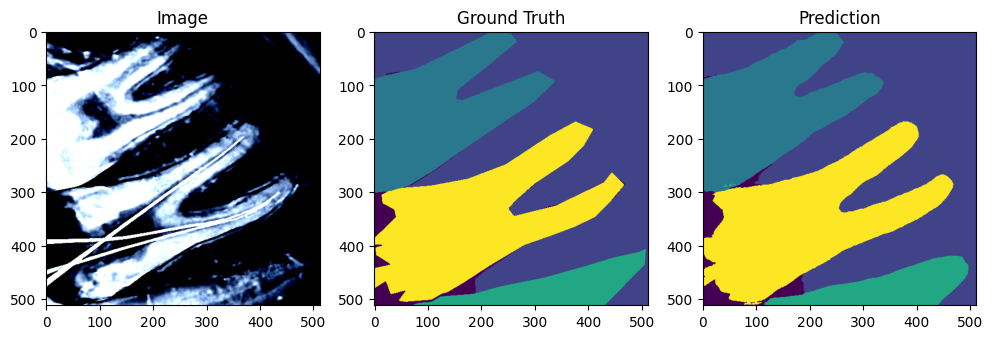

In [18]:
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)

preds = model(imgs)
preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(np.transpose(imgs[0].cpu(), (1, 2, 0)))

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(masks[0])

plt.subplot(1, 3, 3)
plt.title("Prediction")
plt.imshow(preds[0])

plt.show()

In [19]:
torch.save(model.state_dict(), "dental_unet_resnet50.pth")